# 1.0 Strategy
This notebook implements a pair-wise statistical arbitrage strategy based on a given basket of stocks. 

**Strategy Name**: Cointegrated Pairs Trading

**Stocks**: [
    "NVDA",
    "MSFT",
    "AAPL",
    "AMZN",
    "META",
    "AVGO",
    "GOOGL",
    "TSLA",
    "GOOG",
    "BRK-B"
]

**Frequency**: Daily

**Training Date Range**: 1st Jan 2010 - 31st Dec 2016

**Testing Date Range**: 1st Jan 2017 - 31st Dec 2019

**Starting Capital**: $500,000

## Intuition
We aim to find linked pair(s) of stocks within the given basket. We expect a linked, or cointegrated pair, will have price movements that tend to move together over the long term. We expect that the spread of their prices will remain fairly stable, with the spread within a certain range. 

In the event that their spread widens (e.g one side of the pair is performing better than expected and/or the other is underperforming) or narrows more than expected, we would expect the spread to eventually revert as the pair is cointegrated. 

If the spread widens more than expected, we would take a long position on the underperforming stock and a short position on the overperforming stock, as this represents our expectation that the spread will eventually narrow.

If the spread narrows more than expected, we would take a short position on the underperforming stock and a long position on the overperforming stock, as this represents our expectation that the spread will eventually widen.

*TLDR: This strategy resembles mean reversion - but rather than expecting a stock's **price** to return to a mean, we look at a pair's **spread**.*

## Execution
After the `signals` and `hedge_ratios` dataframes are created, we iterate over each time step in the data period. 

`signals` represents the signals for all possible pairs based on the basket of stocks. 

At each time step, the signals for each pair is checked. If there is a signal flip (eg. `0 -> 1`) we enter a position.

Unrealised PnL is calculated for each time step. We ensure that intraday price movement is accounted for, as well as interday price movement (e.g pre-market trading).


## Assumptions
1. Profits can be reinvested. 
2. Signals are generated on close data, then executed on following day's open.
3. Positions can be re-entered on the same day (e.g. close off a long position, then immediately enter into a new short position)

## 1. Imports and Setup

In [ ]:
# --------------------------------------------
# Impors and Setup
# --------------------------------------------
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import statsmodels.tsa.stattools as st
from typing import List, Tuple
from datetime import timedelta
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from itertools import product
from pandas.tseries.offsets import BDay

## 2. Data Retrieval Functions

This section contains functions to load and process data for the strategy. It includes functions to fetch stock data and prepare the data for analysis, and returns a DataFrame containing open and close prices for the specified stocks over the given date range.

In [ ]:
# ---------------------------
# Data fetching & preparation
# ---------------------------


def download_data(
    stock_list: List[str], start_date: str, end_date: str
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Creates & downloads open and close price dataframes for given stock list and date range.

    Inputs:
    - stock_list (List[str]): List of stocks
    - start_date (str): Start date in 'YYYY-MM-DD' format
    - end_date (str): End date in 'YYYY-MM-DD' format

    Returns: Tuple[open_df, `close_df`]: A tuple of two DataFrames containing open and close prices respectively.
    """
    data = yf.download(stock_list, start=start_date, end=end_date)
    # Keep only 'Open' and 'Close' prices
    data = data.loc[:, data.columns.get_level_values(0).isin(["Open", "Close"])]

    # Clean data: remove inf and NaN values
    data = data.replace([np.inf, -np.inf], np.nan).dropna()

    # Split into two separate DataFrames
    open_df = data["Open"].astype(float)
    close_df = data["Close"].astype(float)

    return open_df, close_df

# 3. Signal and Hedge Ratio Generation
Signal and Hedge Ratio Generation is done in 3 steps.
1. Identify cointegrated pairs using the Engle-Granger two-step method.
2. Calculate hedge ratios for the identified cointegrated pairs using linear regression.
3. Generate trading signals based on the spread of the cointegrated pairs.

This is done for each pair of stocks in the basket, and repeated over a sliding window of n days to account for changing market conditions, as the relationship between stocks may evolve over time.

# Step 1: Identify Cointegrated Pairs
To identify cointegrated pairs, we use the Engle-Granger two-step method. This involves performing a linear regression between the two stock prices and then testing the residuals of this regression for stationarity using the Augmented Dickey-Fuller (ADF) test. If the residuals are stationary (i.e., the ADF test statistic is less than the critical value at a chosen significance level), we conclude that the two stocks are cointegrated. 

Intuition: Cointegrated pairs have a stable long-term relationship, meaning that while their individual prices may drift apart in the short term, they tend to move together over time. This property is crucial for pairs trading strategies, as it allows us to exploit temporary divergences in their prices.

# Step 2: Calculate Hedge Ratios
Once we have identified cointegrated pairs, we calculate the hedge ratio for each pair using linear regression. The hedge ratio represents the proportion of one stock to hold relative to the other in order to create a market-neutral position.

# Step 3: Generate Trading Signals
Trading signals are generated based on the spread of the cointegrated pairs. The spread is calculated as the difference between the prices of the two stocks, adjusted by the hedge ratio. We then compute the z-score of the spread to standardize it.

Relation of z-score to trading signals:
- If the z-score > threshold, we signal to short the spread (short the overperforming stock and long the underperforming stock).
- If the z-score < -threshold, we signal to long the spread (long the underperforming stock and short the overperforming stock).
- Else, we signal to exit any existing positions.

From there, we create two DataFrames:
1. `signals`: Contains the trading signals for each pair at each time step.
2. `hedge_ratios`: Contains the hedge ratios for each pair at each time step

**Note: If a pair is not cointegrated, we will not trade that pair. This results in signals being defaulted to 0**

In [ ]:
# --------------------------------------------
# Generate signals and hedge ratios
# --------------------------------------------


def generate_signals_and_hedge_ratios(
    close_data: pd.DataFrame,
    tickers: List[str],
    entry_threshold: float = 1.0,
    exit_threshold: float = 1.0,
    coint_threshold: float = 0.01,
    window_size: int = 100,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    TODO: Comment u shit

    """
    # Initialize DataFrames to zeros, using ticker pairs as column names
    signals = pd.DataFrame(
        0,
        index=close_data.index,
        columns=[
            f"{ticker_a}_{ticker_b}"
            for i, ticker_a in enumerate(tickers)
            for j, ticker_b in enumerate(tickers)
            if i < j
        ],
    )
    hedge_ratios = pd.DataFrame(
        0.0,
        index=close_data.index,
        columns=[
            f"{ticker_a}_{ticker_b}"
            for i, ticker_a in enumerate(tickers)
            for j, ticker_b in enumerate(tickers)
            if i < j
        ],
    )

    # Download warmup data based on start date of close_data,and prepend to close_data
    trading_start_date = close_data.index[0]
    warmup_end_date = trading_start_date - BDay(1)
    warmup_start_date = warmup_end_date - timedelta(days=window_size * 2)

    warmup_data_open, warmup_data_close = download_data(
        tickers, warmup_start_date, warmup_end_date
    )

    # Prepend to close_data
    close_data_with_warmup = pd.concat([warmup_data_close, close_data])

    # Loop over all pairs of stocks
    for i, ticker_a in enumerate(tickers):
        for j, ticker_b in enumerate(tickers):
            if i >= j:  # To avoid redundant pairs (A,B) and (B,A)
                continue

            # Extract stock data for the pair (using yesterday's close for today’s position)
            data_a = close_data_with_warmup[ticker_a].shift(1)[
                1:
            ]  # Use yesterday's closing price for stock A
            data_b = close_data_with_warmup[ticker_b].shift(1)[
                1:
            ]  # Use yesterday's closing price for stock B

            # Sliding window regression and cointegration test (using all available data up to current time point)
            for current_date in close_data.index:
                # If current_date is not in signals index, skip
                if current_date not in signals.index:
                    continue

                # Use all data from start to time t (sliding window) exclusive of t
                y = data_a.loc[:current_date].iloc[-window_size:]  # Dependent (stock A)
                x = data_b.loc[:current_date].iloc[-window_size:]  # Independent (stock B)

                # Skip if there's insufficient data ie yfinance doesn't have data for that date
                if len(y) != window_size or len(x) != window_size:
                    continue

                # Ensure index is valid for cointegration test
                y_coint = y.iloc[:-1]
                x_coint = x.iloc[:-1]

                # Perform cointegration test
                _, p_value, _ = st.coint(y_coint, x_coint)

                # Only proceed if the pair is cointegrated
                if p_value >= coint_threshold:
                    continue  # Skip this pair if not cointegrated

                # Add constant term to independent variable for regression
                x_coint = sm.add_constant(x_coint)

                # Perform linear regression to get the hedge ratio (n)
                model = sm.OLS(y_coint, x_coint).fit()
                hedge_ratio = model.params.iloc[
                    1
                ]  # coefficient for stock B (slope coefficient)

                # build spread series over the same expanding window
                spread_series = y - hedge_ratio * x

                # get mean and stddev of spread series
                mu = spread_series.mean()
                sd = spread_series.std(ddof=1)

                last_spread = spread_series.iloc[-1]
                z_score = 0 if sd == 0 else (last_spread - mu) / sd

                # Generate signal based on z-score and thresholds (1 for long, -1 for short, 0 for exit or no position)
                pair_name = f"{ticker_a}_{ticker_b}"
                if z_score < -entry_threshold:  # Long the spread
                    signals.loc[current_date, pair_name] = 1
                elif z_score > entry_threshold:  # Short the spread
                    signals.loc[current_date, pair_name] = -1  #
                elif abs(z_score) < exit_threshold:  # Exit signal
                    continue
                    # signals[pair_name].iloc[t] = 0  # Exit position
                else:
                    continue
                    # signals[pair_name].iloc[t] = 0  # No action

                # Store hedge ratio for the pair
                hedge_ratios.loc[current_date, pair_name] = hedge_ratio
    hedge_ratios = hedge_ratios.apply(lambda x: abs(x))

    return signals, hedge_ratios

# 3.0 PnL and simulation function definitions

Profit and Loss (PnL) is calculated based on the generated signals and hedge ratios. The PnL calculation takes into account both intraday and interday price movements to ensure accurate profit and loss tracking, using the following logic in the table below:

S/N|Signal Change|Action|PnL Calculation
---|--------|-----------|--------------
1|0 -> 0|Do nothing.|N/A
2|0 -> 1|Long spread. Long stock A and short stock B at open prices| Calculate current day's intraday movement based on current day's open and close prices.
3|0 -> -1|Short spread. Short stock A and long stock B at open prices| Calculate current day's intraday movement based on current day's open and close prices.
4|1 -> 1|Maintain long position.|Calculate interday movement based on previous day's close and current day's close prices. Then, add current day's intraday movement based on today's open and close prices.
5|-1 -> -1|Maintain short position.|Calculate interday movement based on previous day's close and current day's close prices. Then, add current day's intraday movement based on today's open and close prices.
6|1 -> 0|Exit long position at open prices.|Calculate interday movement based on previous day's close and current day's open prices.
7|-1 -> 0|Exit short position at open prices.|Calculate interday movement based on previous day's close and current day's open prices.
8|1 -> -1|Reverse from long to short position.|This is essentially Case 6, followed by Case 3, so the PnL is calculated accordingly.
9|-1 -> 1|Reverse from short to long position.|This is essentially Case 7, followed by Case 2, so the PnL is calculated accordingly.

On the last trading day, we close off all open positions at the closing prices to finalise the PnL calculation, and we have a DataFrame containing the PnL at each time step.

In [ ]:
# --------------------------------------------
# CALCULATE PNL
# --------------------------------------------
def create_positions_dict(tickers: List[str]) -> dict:
    """
    Creates a dictionary to hold positions for each ticker pair.

    {'A_B': (qtyA, qtyB), ...}
    """
    positions = {}
    # k: A_B, v: (qtyA, qtyB)
    for i, ticker_a in enumerate(tickers):
        for j, ticker_b in enumerate(tickers):
            if i < j:
                pair_name = f"{ticker_a}_{ticker_b}"
                positions[pair_name] = (0, 0)  # Initialize quantities to zero
    return positions


def calculate_position_sizes(
    total_cash: float,
    priceA: float,
    priceB: float,
    hedge_ratio: float,
    sizing_pct: float = 0.15,
    leverage: float = 1,
) -> Tuple[float, float]:
    """
    Assumes each position is 3% of free cash

    Leverage is applied to position AFTER calculating position sizes.

    Formula derived from:
    Shares_A = C / ((1+n) * Price_A)
    Shares_B = nC / ((1+n) * Price_B)

    Where C is position size and n is hedge ratio (as decimal).

    Returns: Tuple of (qtyA, qtyB). Note that qtyB is always positive here; sign is handled in main logic.
    """
    leverage = max(leverage, 1)  # Ensure leverage is at least 1
    position_size = total_cash * sizing_pct * leverage  # position size in $$ value

    qtyA = position_size / ((1 + hedge_ratio) * priceA)
    qtyB = (hedge_ratio * position_size) / ((1 + hedge_ratio) * priceB)

    return qtyA, qtyB


def calculate_transaction_costs(
    # Will always be calculated on open prices
    qtyA: float,
    qtyB: float,
    priceA: float,
    priceB: float,
    transaction_cost: float,
) -> float:
    costA = abs(qtyA * priceA) * transaction_cost
    costB = abs(qtyB * priceB) * transaction_cost
    return costA + costB


def calculate_intraday_long(
    qtyA: float, qtyB: float, openA: float, openB: float, closeA: float, closeB: float
) -> float:
    """
    Calculates intraday PnL when going long on spread. This represents a long pos in A and a short pos in B.

    Given as close - open for A and open - close for B.
    """
    pnlA = qtyA * (closeA - openA)
    pnlB = qtyB * (openB - closeB)
    return pnlA + pnlB


def calculate_intraday_short(
    qtyA: float, qtyB: float, openA: float, openB: float, closeA: float, closeB: float
) -> float:
    """
    Calculates intraday PnL when going short on spread. This represents a short pos in A and a long pos in B.

    Given as open - close for A and close - open for B.
    """
    pnlA = qtyA * (openA - closeA)
    pnlB = qtyB * (closeB - openB)
    return pnlA + pnlB


def calculate_interday_long(
    qtyA: float,
    qtyB: float,
    closeA_prev: float,
    closeB_prev: float,
    openA: float,
    openB: float,
) -> float:
    """
    Calculates interday PnL when going long on spread. This represents a long pos in A and a short pos in B.

    Given as open - prev close for A and prev close - open for B.

    """
    pnlA = qtyA * (openA - closeA_prev)
    pnlB = qtyB * (closeB_prev - openB)
    return pnlA + pnlB


def calculate_interday_short(
    qtyA: float,
    qtyB: float,
    closeA_prev: float,
    closeB_prev: float,
    openA: float,
    openB: float,
) -> float:
    """
    Calculates interday PnL when going short on spread. This represents a short pos in A and a long pos in B.

    Given as prev close - open for A and open - prev close for B.
    """
    pnlA = qtyA * (closeA_prev - openA)
    pnlB = qtyB * (openB - closeB_prev)
    return pnlA + pnlB


# ----------- HELPERS END ---------


def calculate_pnl_from_signals_and_hedge_ratios(
    signals: pd.DataFrame,
    tickers: List[str],
    hedge_ratios: pd.DataFrame,
    open_data: pd.DataFrame,
    close_data: pd.DataFrame,
    cash: float = 500000,
    transaction_cost_pct: float = 0.0,
    leverage: float = 1,
) -> tuple[pd.Series, pd.Series]:
    """
    Calculates daily PnL based on generated signals and hedge ratios.

    Returns daily PnL series and daily cash position series.
    """

    assert (
        len(signals) == len(hedge_ratios) == len(open_data) == len(close_data)
    ), "DataFrames must have the same length"

    # init data structures
    positions = create_positions_dict(tickers)
    pnl_series = pd.Series(0.0, index=signals.index)
    cash_series = pd.Series(0.0, index=signals.index)
    cash_series.iloc[0] = cash

    # loop through each time point
    # start from start day till last day
    for t in range(len(signals)):
        current_signals: pd.Series = signals.iloc[t]
        current_hedge_ratios: pd.Series = hedge_ratios.iloc[t]
        open_prices: pd.Series = open_data.iloc[t]
        close_prices: pd.Series = close_data.iloc[t]
        prev_signals: pd.Series = (
            signals.iloc[t - 1] if t > 0 else pd.Series(0, index=signals.columns)
        )
        prev_close_prices: pd.Series = (
            close_data.iloc[t - 1]
            if t > 0
            else pd.Series(0.0, index=close_data.columns)
        )

        for pair in signals.columns:
            signal = current_signals[pair]
            hedge_ratio = current_hedge_ratios[pair]
            tickerA, tickerB = pair.split("_")
            openA = open_prices[tickerA]
            openB = open_prices[tickerB]
            closeA = close_prices[tickerA]
            closeB = close_prices[tickerB]
            prev_signal = prev_signals[pair]
            closeA_prev = prev_close_prices[tickerA]
            closeB_prev = prev_close_prices[tickerB]

            # Case 1: 0 -> 0 : Do nothing
            if prev_signal == 0 and signal == 0:
                continue
            # Case 2: 0 -> 1 : Enter long position
            elif prev_signal == 0 and signal == 1:
                # Calculate position sizes
                new_qtyA, new_qtyB = calculate_position_sizes(
                    cash, openA, openB, hedge_ratio, leverage=leverage
                )
                transaction_cost_entry = calculate_transaction_costs(
                    new_qtyA, new_qtyB, openA, openB, transaction_cost_pct
                )
                purchase_cost = (openA * new_qtyA) - (
                    openB * new_qtyB
                )  # Cost = Buy A - Sell B. if positive, cash outflow
                cash -= transaction_cost_entry
                cash -= purchase_cost
                pnl_series.iloc[t] -= transaction_cost_entry
                pnl_series.iloc[t] += calculate_intraday_long(
                    new_qtyA, new_qtyB, openA, openB, closeA, closeB
                )
                cash_series.iloc[t] = cash 

                positions[pair] = (new_qtyA, new_qtyB)
            # Case 3: 0 -> -1 : Enter short position
            elif prev_signal == 0 and signal == -1:
                # Calculate position sizes
                new_qtyA, new_qtyB = calculate_position_sizes(
                    cash, openA, openB, hedge_ratio, leverage=leverage
                )
                transaction_cost_entry = calculate_transaction_costs(
                    new_qtyA, new_qtyB, openA, openB, transaction_cost_pct
                )
                purchase_cost = (openB * new_qtyB) - (
                    openA * new_qtyA
                )  # Cost = Buy B - Sell A. if positive, cash outflow
                cash -= transaction_cost_entry
                cash -= purchase_cost
                pnl_series.iloc[t] -= transaction_cost_entry
                pnl_series.iloc[t] += calculate_intraday_short(
                    new_qtyA, new_qtyB, openA, openB, closeA, closeB
                )
                cash_series.iloc[t] = cash

                positions[pair] = (new_qtyA, new_qtyB)

            # Case 4: 1 -> 1 : Maintain long position
            elif prev_signal == 1 and signal == 1:
                qtyA, qtyB = positions[pair]
                pnl_series.iloc[t] += calculate_interday_long(
                    qtyA, qtyB, closeA_prev, closeB_prev, openA, openB
                )
                pnl_series.iloc[t] += calculate_intraday_long(
                    qtyA, qtyB, openA, openB, closeA, closeB
                )
                cash_series.iloc[t] = cash  # TODO: REMOVE
            # case 5: -1 -> -1 : Maintain short position
            elif prev_signal == -1 and signal == -1:
                qtyA, qtyB = positions[pair]
                pnl_series.iloc[t] += calculate_interday_short(
                    qtyA, qtyB, closeA_prev, closeB_prev, openA, openB
                )
                pnl_series.iloc[t] += calculate_intraday_short(
                    qtyA, qtyB, openA, openB, closeA, closeB
                )
                cash_series.iloc[t] = cash  # TODO: REMOVE
            # Case 6: 1 -> 0 : Exit long position
            elif prev_signal == 1 and signal == 0:
                qtyA, qtyB = positions[pair]
                # Close existing long position at open
                transaction_costs_exit = calculate_transaction_costs(
                    qtyA, qtyB, openA, openB, transaction_cost_pct
                )

                pnl_series.iloc[t] -= transaction_costs_exit
                pnl_series.iloc[t] += calculate_interday_long(
                    qtyA, qtyB, closeA_prev, closeB_prev, openA, openB
                )
                cash -= transaction_costs_exit
                cash += qtyA * openA  # sell A
                cash -= qtyB * openB  # buy B back.
                cash_series.iloc[t] = cash

                positions[pair] = (0, 0)  # Reset positions

            # Case 7: -1 -> 0 : Exit short position
            elif prev_signal == -1 and signal == 0:
                qtyA, qtyB = positions[pair]
                # Close existing short position at open
                transaction_costs_exit = calculate_transaction_costs(
                    qtyA, qtyB, openA, openB, transaction_cost_pct
                )

                pnl_series.iloc[t] -= transaction_costs_exit
                pnl_series.iloc[t] += calculate_interday_short(
                    qtyA, qtyB, closeA_prev, closeB_prev, openA, openB
                )
                cash -= transaction_costs_exit
                cash += qtyB * openB  # sell B
                cash -= qtyA * openA  # buy A back.
                cash_series.iloc[t] = cash  # TODO: REMOVE
                positions[pair] = (0, 0)  # Reset positions

            # Case 8: 1 -> -1 : Reverse from long to short
            elif prev_signal == 1 and signal == -1:
                # From long to short
                qtyA, qtyB = positions[pair]
                # 1. close existing long position at open ie 1 -> 0
                transaction_costs_exit = calculate_transaction_costs(
                    qtyA, qtyB, openA, openB, transaction_cost_pct
                )

                pnl_series.iloc[t] -= transaction_costs_exit
                pnl_series.iloc[t] += calculate_interday_long(
                    qtyA, qtyB, closeA_prev, closeB_prev, openA, openB
                )
                cash -= transaction_costs_exit
                cash += qtyA * openA  # sell A
                cash -= qtyB * openB  # buy B back

                cash_series.iloc[t] = cash  # TODO: REMOVE
                # 2. enter new short position at open ie 0 -> -1
                new_qtyA, new_qtyB = calculate_position_sizes(
                    cash, openA, openB, hedge_ratio, leverage=leverage
                )
                transaction_cost_entry = calculate_transaction_costs(
                    new_qtyA, new_qtyB, openA, openB, transaction_cost_pct
                )
                purchase_cost = (new_qtyB * openB) - (
                    new_qtyA * openA
                )  # cost = buy B - sell A. if positive, cash outflow
                cash -= transaction_cost_entry
                cash -= purchase_cost
                pnl_series.iloc[t] -= transaction_cost_entry
                pnl_series.iloc[t] += calculate_intraday_short(
                    new_qtyA, new_qtyB, openA, openB, closeA, closeB
                )
                cash_series.iloc[t] = cash  
                positions[pair] = (new_qtyA, new_qtyB)

            # Case 9: -1 -> 1 : Reverse from short to long
            elif prev_signal == -1 and signal == 1:
                # From short to long
                qtyA, qtyB = positions[pair]
                # 1. close existing short position at open
                transaction_costs_exit = calculate_transaction_costs(
                    qtyA, qtyB, openA, openB, transaction_cost_pct
                )

                pnl_series.iloc[t] -= transaction_costs_exit
                pnl_series.iloc[t] += calculate_interday_short(
                    qtyA, qtyB, closeA_prev, closeB_prev, openA, openB
                )
                cash -= transaction_costs_exit
                cash += qtyB * openB  # sell B
                cash -= qtyA * openA  # buy A back.
                cash_series.iloc[t] = cash  # TODO: REMOVE

                # 2. enter new long position at open
                new_qtyA, new_qtyB = calculate_position_sizes(
                    cash, openA, openB, hedge_ratio, leverage=leverage
                )
                transaction_cost_entry = calculate_transaction_costs(
                    new_qtyA, new_qtyB, openA, openB, transaction_cost_pct
                )
                purchase_cost = (new_qtyA * openA) - (
                    new_qtyB * openB
                )  # cost = buy A - sell B. if positive, cash outflow
                cash -= transaction_cost_entry
                cash -= purchase_cost
                pnl_series.iloc[t] -= transaction_cost_entry
                pnl_series.iloc[t] += calculate_intraday_long(
                    new_qtyA, new_qtyB, openA, openB, closeA, closeB
                )
                cash_series.iloc[t] = cash 
                positions[pair] = (new_qtyA, new_qtyB)
        # end of all pairs for current time t
        cash_series.iloc[t] = cash

    # end of all time points
    # close out all open positions
    for pair, (qtyA, qtyB) in positions.items():
        if qtyA == 0 and qtyB == 0:
            continue  # No open position to close
        tickerA, tickerB = pair.split("_")
        closeA = close_data[tickerA].iloc[-1]
        closeB = close_data[tickerB].iloc[-1]

        if signals[pair].iloc[-1] == 1:
            # Closing long position
            transaction_costs_exit = calculate_transaction_costs(
                qtyA, qtyB, closeA, closeB, transaction_cost_pct
            )
            pnl_series.iloc[-1] -= transaction_costs_exit

            cash -= transaction_costs_exit
            cash += qtyA * closeA  # sell A
            cash -= qtyB * closeB  # buy B back.
            cash_series.iloc[-1] = cash
        elif signals[pair].iloc[-1] == -1:
            # Closing short position
            transaction_costs_exit = calculate_transaction_costs(
                qtyA, qtyB, closeA, closeB, transaction_cost_pct
            )
            pnl_series.iloc[-1] -= transaction_costs_exit

            cash -= transaction_costs_exit
            cash += qtyB * closeB  # sell B
            cash -= qtyA * closeA  # buy A back.
            cash_series.iloc[-1] = cash

    return pnl_series, cash_series

## 4. Performance Metrics and Plots
This section calculates key performance metrics to evaluate the effectiveness of the pairs trading strategy. The list of metrics calculated include:
1. Total Return ($)
2. Total Return (%)
3. Annualized Return (%)
4. Annualized Volatility (%)
5. Sharpe Ratio
6. Sortino Ratio
7. Calmar Ratio
8. Treynor Ratio
9. Information Ratio
10. Max Drawdown (%)
11. Max Drawdown Duration (days)
12. Beta
13. Alpha

In [ ]:
# ----------------------------------
# Performance Metrics
# ----------------------------------


def get_performance_metrics(
    pnl_series: pd.Series, benchmark_ticker="SPY", cash=500_000
) -> dict:
    """
    Calculates performance metrics from PnL series.

    Returns a dictionary of performance metrics.
    """

    # 1. Calculate Portfolio Value Time Series
    # Portfolio value = Initial cash + cumulative PnL
    portfolio_value = cash + pnl_series.cumsum()

    # 2. Total Return ($) and Total Return (%)
    total_return = portfolio_value.iloc[-1] - cash  # Total PnL ($)
    total_return_pct = (total_return / cash) * 100  # Total return (%)

    # 3. Annualized Return (%)
    num_days = len(pnl_series)
    annualized_return = (
        (portfolio_value.iloc[-1] / cash) ** (252 / num_days)
    ) - 1  # Annualized Return Formula

    # 4. Daily Returns from Portfolio Value
    daily_returns = portfolio_value.pct_change().dropna()  # Daily returns in percentage

    # 5. Annualized Volatility (Standard Deviation %)
    annualized_volatility = daily_returns.std() * np.sqrt(
        252
    )  # Annualized standard deviation

    # 6. Sharpe Ratio
    if annualized_volatility != 0:
        sharpe_ratio = annualized_return / annualized_volatility
    else:
        sharpe_ratio = np.nan

    # 7. Sortino Ratio (using downside deviation)
    downside_returns = daily_returns[daily_returns < 0]
    downside_volatility = downside_returns.std() * np.sqrt(
        252
    )  # Annualized downside deviation
    if downside_volatility != 0:
        sortino_ratio = annualized_return / downside_volatility
    else:
        sortino_ratio = np.nan

    # 8. Calmar Ratio (Annualized Return / Max Drawdown)
    max_drawdown = calculate_max_drawdown(portfolio_value)
    calmar_ratio = annualized_return / max_drawdown if max_drawdown != 0 else np.nan

    # 9. Treynor Ratio (Annualized Return / Beta)
    beta = calculate_beta(portfolio_value, benchmark_ticker)
    treynor_ratio = annualized_return / beta if beta != 0 else np.nan

    # 10. Information Ratio (Annualized Excess Return over Benchmark / Tracking Error)
    benchmark_data = yf.download(
        benchmark_ticker, start=pnl_series.index[0], end=pnl_series.index[-1]
    )["Close"]
    benchmark_data = benchmark_data.squeeze()
    benchmark_returns = benchmark_data.pct_change().dropna()  # Benchmark returns
    # Align daily returns with benchmark returns
    aligned_data = daily_returns.align(benchmark_returns, join="inner")
    daily_returns = aligned_data[0]
    benchmark_returns = aligned_data[1]
    excess_returns = daily_returns - benchmark_returns  # Excess returns
    tracking_error = excess_returns.std() * np.sqrt(252)  # Tracking error
    info_ratio = annualized_return / tracking_error if tracking_error != 0 else np.nan

    # 11. Max Drawdown (%)
    max_drawdown_pct = max_drawdown * 100  # Percentage

    # 12. Max Drawdown Duration (days)
    max_drawdown_duration = calculate_max_drawdown_duration(portfolio_value)

    # 13. Beta
    # already calculated with treynor

    # 14. Alpha (assuming risk-free rate is 0)
    alpha = calculate_alpha(portfolio_value, benchmark_ticker)

    return {
        "Total Return ($)": round(float(total_return), 2),
        "Total Return (%)": round(float(total_return_pct), 2),
        "Annualized Return (%)": round(float(annualized_return * 100), 2),
        "Annualized Volatility (%)": round(float(annualized_volatility * 100), 2),
        "Sharpe Ratio": round(float(sharpe_ratio), 2),
        "Sortino Ratio": (
            round(float(sortino_ratio), 2) if sortino_ratio is not np.nan else np.nan
        ),
        "Calmar Ratio": (
            round(float(calmar_ratio), 2) if calmar_ratio is not np.nan else np.nan
        ),
        "Treynor Ratio": (
            round(float(treynor_ratio), 2) if treynor_ratio is not np.nan else np.nan
        ),
        "Information Ratio": (
            round(float(info_ratio), 2) if info_ratio is not np.nan else np.nan
        ),
        "Max Drawdown (%)": (
            round(float(max_drawdown_pct), 2)
            if max_drawdown_pct is not np.nan
            else np.nan
        ),
        "Max Drawdown Duration (days)": (
            round(float(max_drawdown_duration), 2)
            if max_drawdown_duration is not np.nan
            else np.nan
        ),
        "Beta": round(float(beta), 5) if beta is not np.nan else np.nan,
        "Alpha": round(float(alpha), 2) if alpha is not np.nan else np.nan,
    }


# Helper functions for max drawdown, beta, and alpha calculations:


def calculate_max_drawdown(portfolio_value: pd.Series) -> float:
    """Calculate the maximum drawdown as a percentage of total capital."""
    peak = portfolio_value.cummax()
    drawdown = (portfolio_value - peak) / peak
    max_drawdown = drawdown.min()
    return max_drawdown


def calculate_max_drawdown_duration(portfolio_value: pd.Series) -> int:
    """Calculate the duration of the maximum drawdown."""
    peak = portfolio_value.cummax()
    drawdown = (portfolio_value - peak) / peak

    # Find the periods where drawdown is negative
    drawdown_days = drawdown[drawdown < 0]

    # Track the length of the longest consecutive negative drawdown
    max_duration = 0
    current_duration = 0

    for day in drawdown_days:
        if day < 0:  # If it's part of a drawdown
            current_duration += 1
        else:  # If the drawdown ends
            max_duration = max(max_duration, current_duration)
            current_duration = 0

    # Check the last drawdown duration in case it ended at the last day
    max_duration = max(max_duration, current_duration)

    return max_duration


def calculate_beta(portfolio_value: pd.Series, benchmark_ticker: str) -> float:
    """Calculate the beta (sensitivity to benchmark) using covariance and variance."""
    # Download benchmark data (e.g., SPY) for the same period as the portfolio_value series

    benchmark_data = yf.download(
        benchmark_ticker, start=portfolio_value.index[0], end=portfolio_value.index[-1]
    )["Close"]

    # Calculate daily returns for both the stock (portfolio rets) and the benchmark
    stock_returns = (
        portfolio_value.pct_change().dropna()
    )  # Calculate portfolio daily returns
    benchmark_returns = (
        benchmark_data.pct_change().dropna()
    )  # Calculate benchmark daily returns
    # Ensure both series are aligned (same index)
    aligned_data = stock_returns.align(benchmark_returns, join="inner")
    stock_returns = aligned_data[0]
    benchmark_returns = aligned_data[1]

    # change benchmark_returns from multi index df to df
    benchmark_returns = benchmark_returns.squeeze()

    # Calculate covariance between stock returns and benchmark returns
    covariance = np.cov(stock_returns, benchmark_returns)[0, 1]  # Covariance

    # Calculate variance of benchmark returns
    benchmark_variance = benchmark_returns.var()  # Variance of the benchmark returns

    # Calculate beta (covariance / variance)
    if benchmark_variance != 0:
        beta = covariance / benchmark_variance
    else:
        beta = np.nan  # If benchmark variance is zero, beta can't be calculated

    return beta


def calculate_alpha(portfolio_value: pd.Series, benchmark_ticker: str) -> float:
    """Calculate the alpha (excess return) of the portfolio."""
    beta = calculate_beta(portfolio_value, benchmark_ticker)
    benchmark_data = yf.download(
        benchmark_ticker, start=portfolio_value.index[0], end=portfolio_value.index[-1]
    )["Close"]
    benchmark_data = benchmark_data.squeeze()
    benchmark_returns = benchmark_data.pct_change().dropna()
    portfolio_returns = portfolio_value.pct_change().dropna()
    # Align returns
    aligned_data = portfolio_returns.align(benchmark_returns, join="inner")
    portfolio_returns = aligned_data[0]
    benchmark_returns = aligned_data[1]
    excess_returns = portfolio_returns - beta * benchmark_returns
    alpha = excess_returns.mean() * 252  # Annualize alpha
    return alpha

# 5. Plot Figures

This section contains code to plot various figures to visualize the performance of the pairs trading strategy. The plots include:
1. Histogram of Daily Returns: A histogram showing the distribution of daily returns of the strategy.
2. Strategy vs Benchmarks Line Chart: A line chart comparing the cumulative returns of the strategy against benchmark indices and long-only strategy.
3. Max Drawdown vs Cumulative Returns: A line chart illustrating the maximum drawdown in relation to cumulative returns over time.
4. Equity Curve: A line chart showing the growth of the strategy's equity over time.

These visualizations help in understanding the strategy's performance and risk characteristics over the testing period.

In [6]:
# ------------------------
# Plot Figures
# ------------------------


def plot_figures(
    pnl_series: pd.Series,
    benchmark_ticker: str,
    tickers: List[str],
    cash: float = 500_000,
) -> None:
    """
    Plots various performance figures in a single plot:
    1. Histogram of strategy returns (daily pct change).
    2. Strategy vs. Benchmark performance (SPY) and Long on Basket.
    3. Max Drawdown vs. Portfolio Cumulative Log Return.
    4. Equity Curve (Portfolio Value over time).
    """

    # Ensure the pnl_series is properly aligned and the index is datetime
    pnl_series = pnl_series.sort_index()
    portfolio_value = cash + pnl_series.cumsum()

    # Create a figure with 2x2 grid of subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))  # 2 rows, 2 columns
    axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easy iteration

    # 1. Histogram of Strategy Returns
    daily_returns = (
        portfolio_value.pct_change().dropna()
    )  # Convert PnL to daily returns in % terms
    axes[0].hist(
        daily_returns, bins=30, alpha=0.75, color="blue", label="Strategy Returns"
    )
    axes[0].set_title("Histogram of Strategy Returns")
    axes[0].set_xlabel("Daily Returns")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True)
    axes[0].legend(loc="best")

    # 2. Strategy vs. Benchmark (SPY) vs. Long on Basket
    # Download SPY data and calculate returns
    benchmark_data = yf.download(
        benchmark_ticker, start=pnl_series.index[0], end=pnl_series.index[-1]
    )["Close"]
    benchmark_returns = benchmark_data.pct_change().dropna()

    # Calculate returns for the basket (long all stocks)
    basket_data = yf.download(
        tickers, start=pnl_series.index[0], end=pnl_series.index[-1]
    )["Close"]
    basket_returns = (
        basket_data.pct_change().mean(axis=1).dropna()
    )  # Simple mean of all stock returns

    # Calculate cumulative returns for the strategy, SPY, and long basket
    strategy_cumulative_returns = (1 + daily_returns).cumprod() - 1
    benchmark_cumulative_returns = (1 + benchmark_returns).cumprod() - 1
    basket_cumulative_returns = (1 + basket_returns).cumprod() - 1

    # Plot strategy vs benchmark vs long basket
    axes[1].plot(strategy_cumulative_returns, label="Strategy", color="blue")
    axes[1].plot(
        benchmark_cumulative_returns,
        label=f"{benchmark_ticker} (Benchmark)",
        color="red",
        linestyle="--",
    )
    axes[1].plot(
        basket_cumulative_returns, label="Long Basket", color="green", linestyle=":"
    )
    axes[1].set_title("Strategy vs Benchmark vs Long Basket")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Cumulative Return")
    axes[1].legend()
    axes[1].grid(True)

    # 3. Max Drawdown vs. Portfolio Cumulative Log Return
    cumulative_returns = (1 + daily_returns).cumprod() - 1
    peak = cumulative_returns.cummax()  # The peak value at each point
    drawdown = cumulative_returns - peak  # The drawdown at each point
    max_drawdown = drawdown.min()  # The maximum drawdown (most negative value)

    # Plot cumulative returns and peak
    axes[2].plot(cumulative_returns, label="Cumulative Returns", color="blue")
    axes[2].plot(
        peak, label="Cummax (Peak Cumulative Returns)", color="green", linestyle="--"
    )

    # Fill the drawdown area
    axes[2].fill_between(
        cumulative_returns.index,
        cumulative_returns,
        peak,
        where=(cumulative_returns < peak),  # Only fill where drawdown occurs
        color="red",
        alpha=0.3,
        label="Drawdown",
    )

    # Set the title and labels
    axes[2].set_title(f"Max Drawdown: {max_drawdown:.2%}")
    axes[2].set_xlabel("Date")
    axes[2].set_ylabel("Cumulative Return")
    axes[2].legend()
    axes[2].grid(True)

    # 4. Equity Curve (Portfolio Value over Time)
    equity_curve = (1 + daily_returns).cumprod() * cash  # Portfolio value over time
    axes[3].plot(equity_curve, label="Equity Curve (Portfolio Value)", color="green")
    axes[3].set_title("Equity Curve (Portfolio Value Over Time)")
    axes[3].set_xlabel("Date")
    axes[3].set_ylabel("Portfolio Value ($)")
    axes[3].legend()
    axes[3].grid(True)

    # Adjust layout
    plt.tight_layout()
    plt.show()

## 6. Parameter Search

This section defines the function for parameter searching, which will be used later to optimize the strategy's performance by testing different combinations of key parameters in the test period.

We modify 3 variables:
- `entry_threshold`: The entry threshold for generating trading signals. A higher threshold means that the spread must deviate more from its mean before a trade is initiated.
- `lookback_window`: The lookback window size determines how far the sliding window extends when calculating cointegration and hedge ratios. Generally, a longer lookback window provides more data for analysis but may be less responsive to recent market changes. Moreover, it takes longer to compute signals and hedge ratios.
- `p-value`: The p-value threshold for the cointegration test. A lower p-value indicates stronger evidence against the null hypothesis of no cointegration, meaning the pair is more likely to be cointegrated.

Using the `param_search` function, we run the full simulation on every combination of the 3 variables provided, then sort the results by the best Sharpe Ratio. 

This version of `param_search` also allows for faster execution by parallelizing jobs - set to use all available cores by default.

In [ ]:
# ----------------------------------
# PARAM SEARCH PARALLELIZED
# ----------------------------------


# Define param search with parallelization
def param_search(
    param_grid: dict,
    close_data: pd.DataFrame,
    open_data: pd.DataFrame,
    tickers: List[str],
    cash: float = 500_000,
    transaction_cost_pct: float = 0.0,
    leverage: float = 1,
    n_jobs: int = -1,  # n_jobs: -1 will use all available cores
) -> pd.DataFrame:
    """
    Performs parameter search over the given grid and returns performance metrics for each combination,
    using parallel processing to speed up the search.
    """
    # Create all combinations of parameters
    keys, values = zip(*param_grid.items())
    param_combinations = [dict(zip(keys, v)) for v in product(*values)]

    # Function to process each parameter combination and return the performance metrics
    def process_param_combination(params):
        #print(f"Testing parameters: {params}")
        signals, hedge_ratios = generate_signals_and_hedge_ratios(
            close_data,
            tickers,
            entry_threshold=params["entry_threshold"],
            exit_threshold=params["entry_threshold"],  # exit threshold same as entry
            window_size=params["lookback_window"],
            coint_threshold=params["p-value"],
        )

        pnl_series, _ = calculate_pnl_from_signals_and_hedge_ratios(
            signals,
            tickers,
            hedge_ratios,
            open_data,
            close_data,
            cash=cash,
            transaction_cost_pct=transaction_cost_pct,
            leverage=leverage,
        )

        metrics = get_performance_metrics(pnl_series, benchmark_ticker="SPY", cash=cash)
        metrics.update(params)
        return tuple(params.items()), metrics

    # Parallelize the process using joblib's Parallel and delayed
    results = Parallel(n_jobs=n_jobs)(
        delayed(process_param_combination)(params) for params in param_combinations
    )

    # Convert results to dictionary
    results_dict = {k: v for k, v in results}

    # Convert results to DataFrame, sorted by Sharpe Ratio
    results_df = pd.DataFrame.from_dict(results_dict, orient="index")
    results_df = results_df.sort_values("Sharpe Ratio", ascending=False)
    results_df = results_df.reset_index()
    return results_df

## 7. Run Backtest

This section runs the backtest of the pairs trading strategy using the defined parameters and functions. 

It executes the full simulation based on the functions and hyperparameters defined in the previous sections, and evaluates the strategy's performance over the testing period, returning the performance metrics and plots for analysis.

In [ ]:
# ----------------------------------
# RUN BACKTEST
# ----------------------------------


def run_backtest(
    start_date: str,
    end_date: str,
    tickers: List[str],
    cash: float = 500_000,
    transaction_cost_pct: float = 0.0,
    leverage: float = 1,
    entry_threshold: float = 1.0,
    exit_threshold: float = 1.0,
    coint_threshold: float = 0.05,
    coint_window: int = 60,
):
    # 1. Download Data
    open_data, close_data = download_data(tickers, start_date, end_date)

    # 2. Generate    Signals and Hedge Ratios
    signals, hedge_ratios = generate_signals_and_hedge_ratios(
        close_data,
        tickers,
        entry_threshold=entry_threshold,
        exit_threshold=exit_threshold,
        coint_threshold=coint_threshold,
        window_size=coint_window,
    )

    # 3. Calculate PnL from Signals and Hedge Ratios
    pnl_series, cash_series = calculate_pnl_from_signals_and_hedge_ratios(
        signals,
        tickers,
        hedge_ratios,
        open_data,
        close_data,
        cash=cash,
        transaction_cost_pct=transaction_cost_pct,
        leverage=leverage,
    )

    # 4. Get Performance Metrics
    performance_metrics = get_performance_metrics(
        pnl_series, benchmark_ticker="SPY", cash=cash
    )

    # 5. Plot Figures
    plot_figures(pnl_series, benchmark_ticker="SPY", tickers=tickers, cash=cash)

    return performance_metrics

# 8. Execution of Parameter Search and Backtest in Training Period

Now that all functions and definitions are in place, we can proceed to execute the parameter search to identify the optimal parameters for our pairs trading strategy. All of the dates and other parameters like leverage and starting cash have been defined below as well.

We define the ranges for each of the three key parameters to test below: `entry_threshold`, `lookback_window`, and `p-value`. 

In [9]:
# --------------------------------------------
# Find best parameters via param search
# --------------------------------------------
params = {
    "entry_threshold": [0.5, 1.0, 1.6, 1.9],
    "lookback_window": [400, 480, 560], 
    "p-value": [0.01, 0.05, 0.1],
}

tickers = [
    "NVDA",
    "MSFT",
    "AAPL",
    "AMZN",
    "META",
    "AVGO",
    "GOOGL",
    "TSLA",
    "GOOG",
    "BRK-B",
]

start_train_date = "2010-01-01"
end_train_date = "2016-12-31"
start_test_date = "2017-01-01"
end_test_date = "2019-12-31"
transaction_cost_pct = 0.0  # pct
leverage = 1  # multiplier
cash = 500000  # starting cash for position sizing

# Download training and testing data
open_train_data, close_train_data = download_data(
    tickers, start_train_date, end_train_date
)
open_test_data, close_test_data = download_data(tickers, start_test_date, end_test_date)

# Perform parameter search on training data
results_df = param_search(
    params,
    close_train_data,
    open_train_data,
    tickers,
    cash=cash,
    transaction_cost_pct=transaction_cost_pct,
    leverage=leverage,
    n_jobs=-1,  # Use all available CPU cores
)

# Save results to CSV
results_df.to_csv("param_search_FINAL.csv", index=False)

C:\Users\jairu\AppData\Local\Temp\ipykernel_25068\3309790914.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_list, start=start_date, end=end_date)
[*********************100%***********************]  10 of 10 completed
C:\Users\jairu\AppData\Local\Temp\ipykernel_25068\3309790914.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_list, start=start_date, end=end_date)
[*********************100%***********************]  10 of 10 completed


## 9. Check Results of Parameter Search in Training Period

After finding the best parameters from the parameter search, we can run the backtest on the training period using these optimal parameters to evaluate the strategy's performance in the training period.

C:\Users\jairu\AppData\Local\Temp\ipykernel_25068\3309790914.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_list, start=start_date, end=end_date)
[**********************70%*********              ]  7 of 10 completed

Best Parameters from Training Set:
{'entry_threshold': 1.9, 'lookback_window': 400, 'p-value': 0.01}


[*********************100%***********************]  10 of 10 completed
C:\Users\jairu\AppData\Local\Temp\ipykernel_25068\3309790914.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_list, start=start_date, end=end_date)
[*********************100%***********************]  10 of 10 completed

1 Failed download:
['META']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-03-09 00:00:00 -> 2012-05-17 00:00:00) (Yahoo error = "Data doesn\'t exist for startDate = 1268110800, endDate = 1337227200")')
C:\Users\jairu\AppData\Local\Temp\ipykernel_25068\1692651467.py:85: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  _, p_value, _ = st.coint(y_coint, x_coint)
C:\Users\jairu\AppData\Local\Temp\ipykernel_25068\1692651467.py:85: CollinearityWarning: y0 and y1 are (almost) perfectly colinear.Cointegration test is not reliable in this case.
  _, p_value,

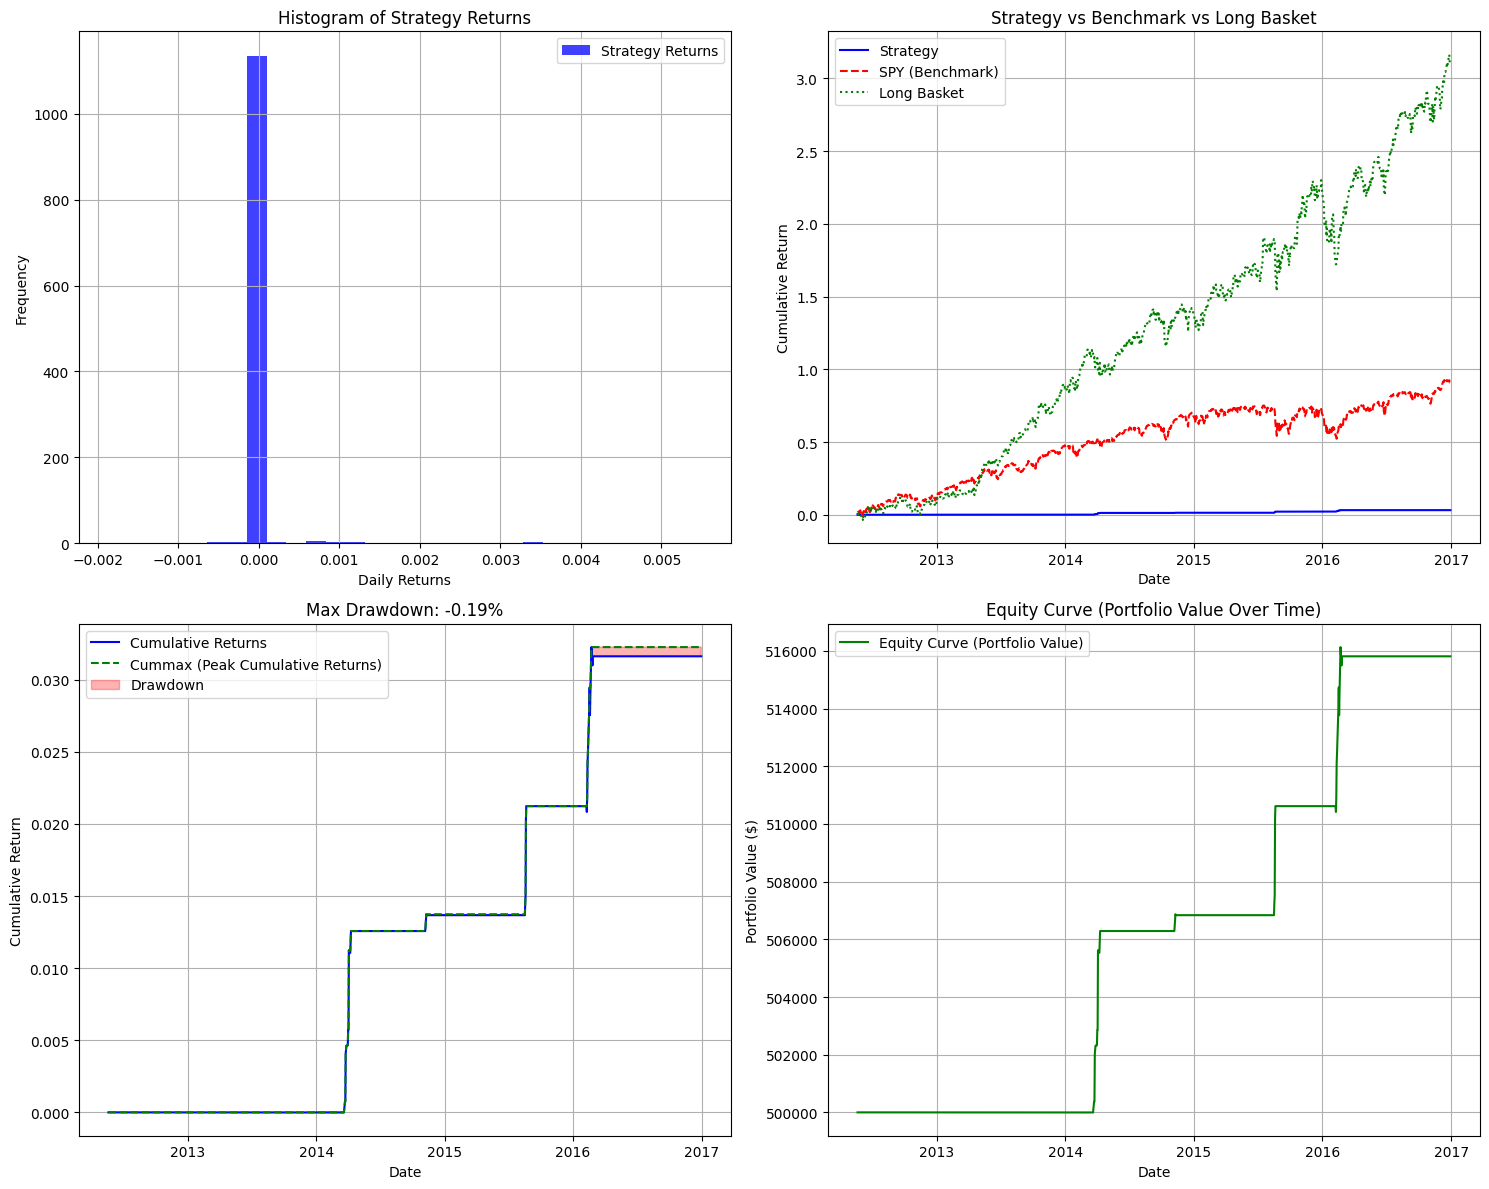

Performance Metrics on Training Set:
Total Return ($): 15813.66
Total Return (%): 3.16
Annualized Return (%): 0.68
Annualized Volatility (%): 0.48
Sharpe Ratio: 1.4
Sortino Ratio: 0.79
Calmar Ratio: -3.63
Treynor Ratio: -3.76
Information Ratio: 0.05
Max Drawdown (%): -0.19
Max Drawdown Duration (days): 472.0
Beta: -0.0018
Alpha: 0.01


In [10]:
# --------------------------------------------
# COMPARE PERFORMANCE METRICS OF TRAIN VS TEST
# --------------------------------------------

# Get best params from train set
best_params = results_df.iloc[0]
# convert params to native python types
best_params = {
    "entry_threshold": float(best_params["entry_threshold"]),
    "lookback_window": int(best_params["lookback_window"]),
    "p-value": float(best_params["p-value"]),    
}

best_params
entry_threshold = best_params["entry_threshold"]
exit_threshold = best_params["entry_threshold"]  # exit same as entry
coint_threshold = best_params["p-value"]
coint_window = best_params["lookback_window"]
print("Best Parameters from Training Set:")
print(best_params)

# Run backtest on train set with best params
results_train = run_backtest(
    start_date=start_train_date,
    end_date=end_train_date,
    tickers=tickers,
    cash=cash,
    transaction_cost_pct=transaction_cost_pct,
    leverage=leverage,
    entry_threshold=entry_threshold,
    exit_threshold=exit_threshold,
    coint_threshold=coint_threshold,
    coint_window=coint_window,
)

print("Performance Metrics on Training Set:")
for metric, value in results_train.items():
    print(f"{metric}: {value}")

# 10. Run Best Parameteres in Test Period

Now, we can run the backtest on the test period using these optimal parameters to evaluate the strategy's performance in the test period.

C:\Users\jairu\AppData\Local\Temp\ipykernel_25068\3309790914.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_list, start=start_date, end=end_date)
[*********************100%***********************]  10 of 10 completed
C:\Users\jairu\AppData\Local\Temp\ipykernel_25068\3309790914.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_list, start=start_date, end=end_date)
[*********************100%***********************]  10 of 10 completed
C:\Users\jairu\AppData\Local\Temp\ipykernel_25068\1143876439.py:160: FutureWarning: YF.download() has changed argument auto_adjust default to True
  benchmark_data = yf.download(
[*********************100%***********************]  1 of 1 completed
C:\Users\jairu\AppData\Local\Temp\ipykernel_25068\1143876439.py:62: FutureWarning: YF.download() has changed argument auto_adjust default to True
  benchmark_data = yf.download(
[*********

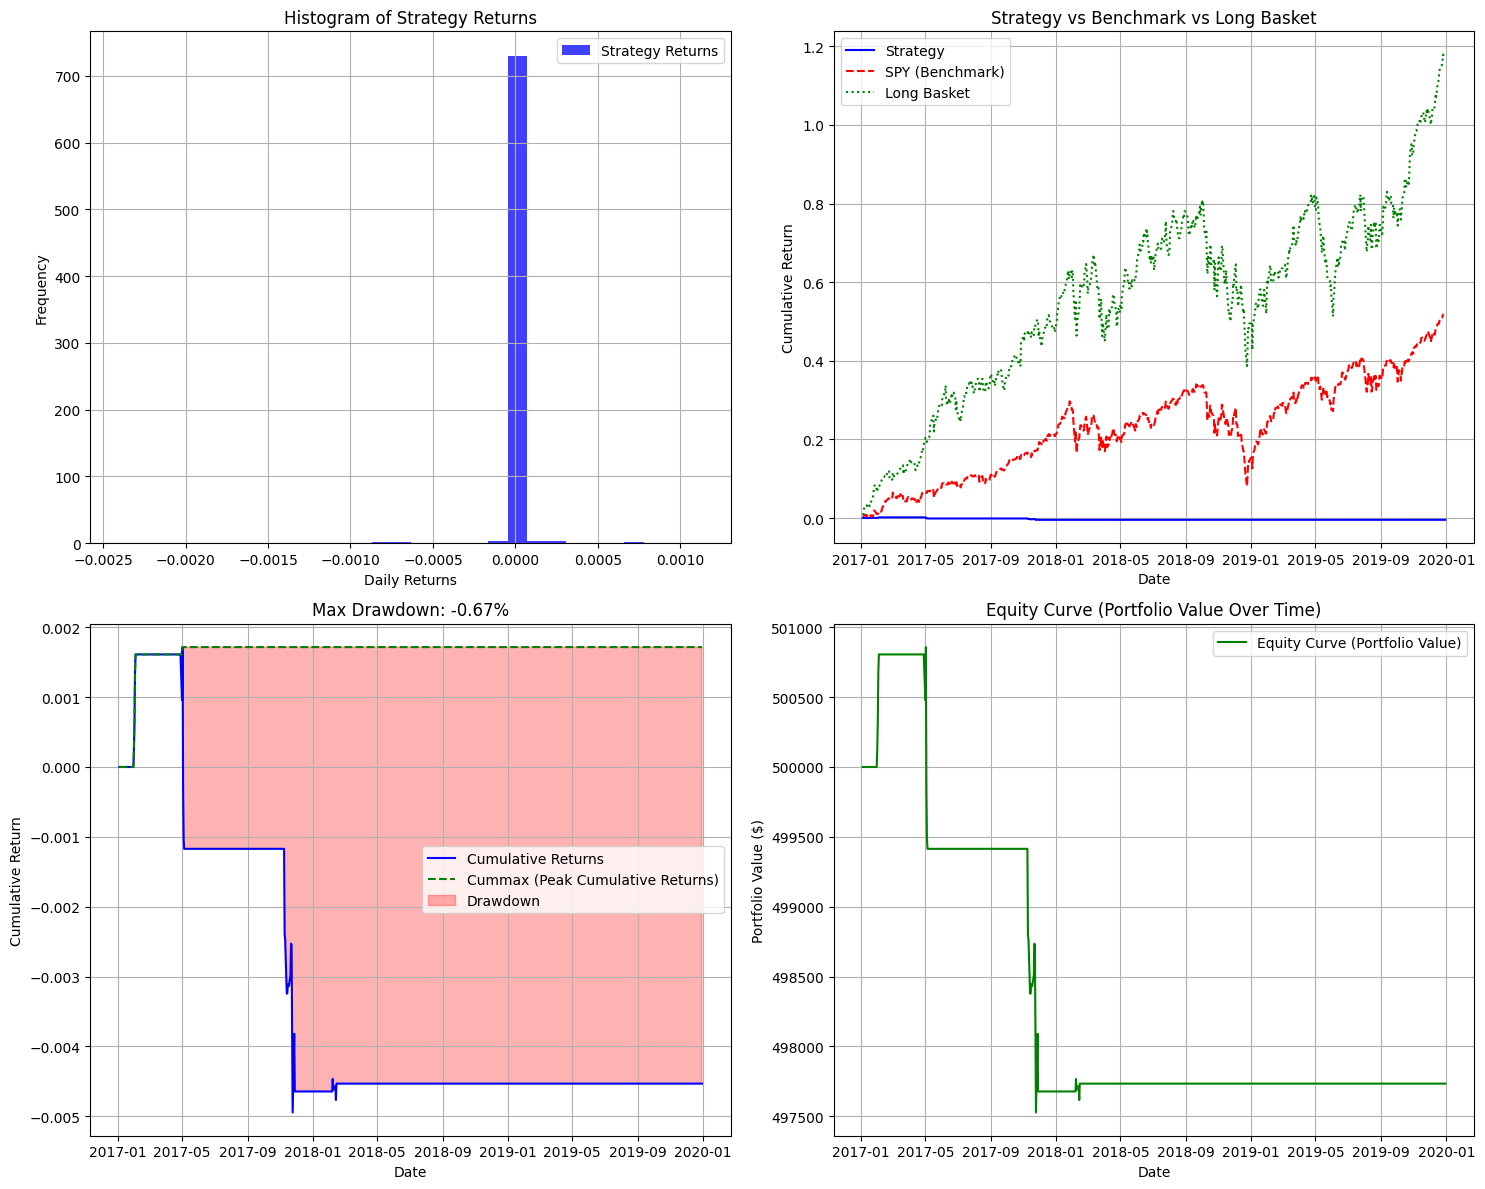

Performance Metrics on Test Set:
Total Return ($): -2266.22
Total Return (%): -0.45
Annualized Return (%): -0.15
Annualized Volatility (%): 0.24
Sharpe Ratio: -0.64
Sortino Ratio: -0.12
Calmar Ratio: 0.23
Treynor Ratio: -15.99
Information Ratio: -0.01
Max Drawdown (%): -0.66
Max Drawdown Duration (days): 671.0
Beta: 0.0001
Alpha: -0.0


In [11]:
# Run backtest on test set with best params

results_test = run_backtest(
    start_date=start_test_date,
    end_date=end_test_date,
    tickers=tickers,
    cash=cash,
    transaction_cost_pct=transaction_cost_pct,
    leverage=leverage,
    entry_threshold=entry_threshold,
    exit_threshold=exit_threshold,
    coint_threshold=coint_threshold,
    coint_window=coint_window,
)

print("Performance Metrics on Test Set:")
for metric, value in results_test.items():
    print(f"{metric}: {value}")

In [ ]:
# --------------------------------------------
# RUN BACKTEST FOR PROF SHASHANK [CELL]
# --------------------------------------------

# -----------------------------------
# FOR PROF TO CHANGE
tickers = [
    "NVDA",
    "MSFT",
    "AAPL",
    "AMZN",
    "META",
    "AVGO",
    "GOOGL",
    "TSLA",
    "GOOG",
    "BRK-B",
]
start_date = "2019-01-01"
end_date = "2019-12-31"
transaction_cost_pct = 0.0  # pct
leverage = 1  # multiplier, set to 0 or 1 for no leverage
cash = 500000  # starting cash for position sizing
# ------------------------------------

# TODO: SET PARAMS BELOW
# BEST PARAMS FROM PARAM SEARCH (DON'T CHANGE)
# ------------------------------------
entry_threshold = 1.9
exit_threshold = 1.9
coint_threshold = 0.01
coint_window = 400
# ------------------------------------

run_backtest(
    start_date=start_date,
    end_date=end_date,
    tickers=tickers,
    cash=cash,
    transaction_cost_pct=transaction_cost_pct,
    leverage=leverage,
    entry_threshold=entry_threshold,
    exit_threshold=entry_threshold,
    coint_threshold=coint_threshold,
    coint_window=coint_window,
)